In [1]:
import pyuvdata
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization import ZScaleInterval, ImageNormalize
import matplotlib.pyplot as plt 
import bdsf

In [2]:
uv = pyuvdata.UVData()
uv.read("/fast/rbyrne/20260419_055641-055832_44MHz_wsclean_selfcal_deep_flagging_tmp_dir/20260419_055641-055832_calico_peeled.ms", ignore_single_chan=False)

In [3]:
def get_pixel_az_za(x_pix, y_pix, header):

    wcs_cel = WCS(header).celestial
    ny, nx = header['NAXIS2'], header['NAXIS1']

    crpix1, crpix2 = header['CRPIX1'] - 1, header['CRPIX2'] - 1
    cd = wcs_cel.pixel_scale_matrix

    y_idx, x_idx = np.mgrid[0:ny, 0:nx]
    dx = x_pix - crpix1
    dy = y_pix - crpix2
    xi  = cd[0, 0]*dx + cd[0, 1]*dy
    eta = cd[1, 0]*dx + cd[1, 1]*dy

    az = np.degrees(np.arctan2(eta, -xi)) % 360.0

    R = 180.0 / np.pi
    r = np.sqrt(xi**2 + eta**2)
    za = np.degrees(np.arcsin(r * np.pi / 180))

    return az, za

In [4]:
with fits.open("/fast/rbyrne/20260419_055641-055832_44MHz_wsclean_selfcal_deep_flagging_tmp_dir/20260419_055641-055832_calico_peeled-dirty.fits") as hdul:
    data = hdul[0].data.squeeze()
    header = hdul[0].header


In [5]:
header

SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                  -32 / number of bits per data pixel                  
NAXIS   =                    4 / number of data axes                            
NAXIS1  =                 4096 / length of data axis 1                          
NAXIS2  =                 4096 / length of data axis 2                          
NAXIS3  =                    1 / length of data axis 3                          
NAXIS4  =                    1 / length of data axis 4                          
EXTEND  =                    T / FITS dataset may contain extensions            
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
BSCALE  =                   1.                                                  
BZERO   =                   0.                                                  
BUNIT   = 'JY/BEAM '        

In [6]:
x_pixels, y_pixels = np.arange(np.shape(data)[0]), np.arange(np.shape(data)[1])
x_pixels_meshgrid, y_pixels_meshgrid = np.meshgrid(x_pixels, y_pixels)
az_vals, za_vals = get_pixel_az_za(x_pixels_meshgrid, y_pixels_meshgrid, header)

invalid value encountered in arcsin


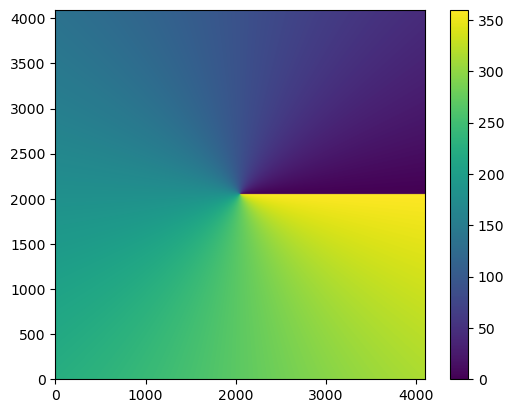

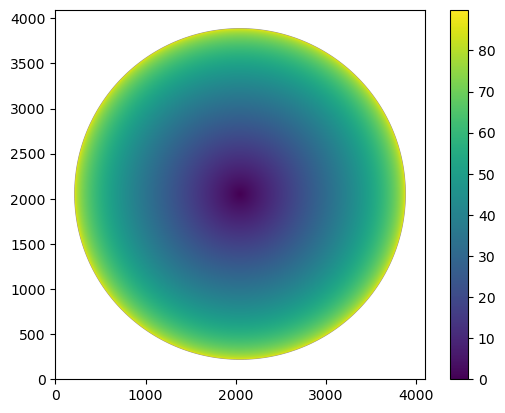

In [7]:
plt.imshow(az_vals, origin="lower", interpolation=None)
plt.colorbar()
plt.show()

plt.imshow(za_vals, origin="lower", interpolation=None)
plt.colorbar()
plt.show()

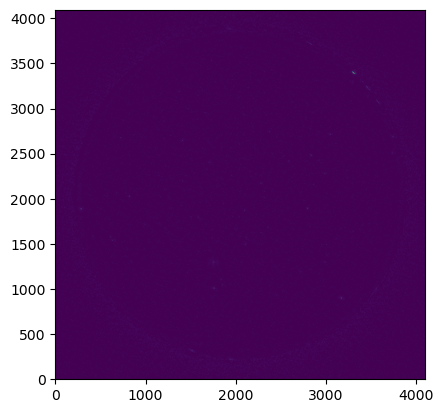

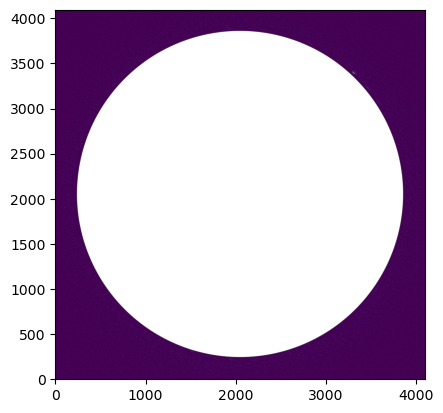

In [8]:
horizon_data = data.copy()
horizon_data[np.where(za_vals < 80)] = np.nan
plt.imshow(data, origin="lower", interpolation=None, vmin=0, vmax=np.nanmax(data))
plt.show()
plt.imshow(horizon_data, origin="lower", interpolation=None, vmin=0, vmax=np.nanmax(horizon_data))
plt.show()

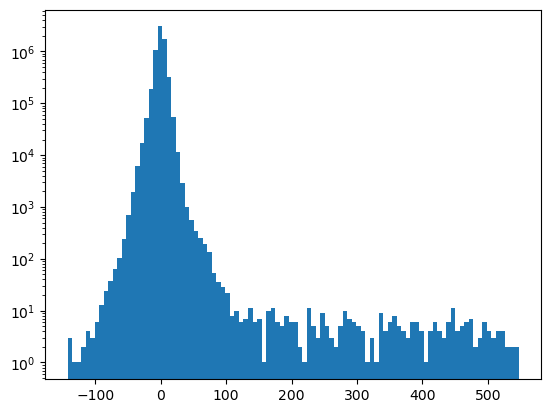

In [9]:
plt.hist(horizon_data.flatten(), bins=100)
plt.yscale("log")

In [10]:
len(np.where(horizon_data > 200)[0])

236

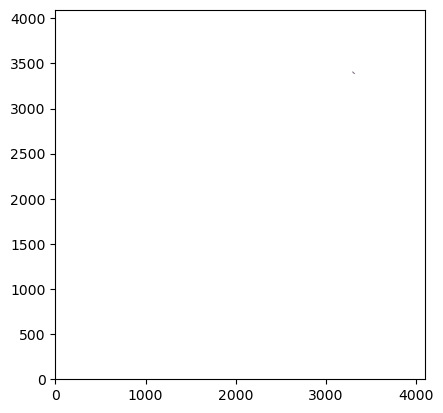

In [11]:
horizon_data_max = np.ones_like(horizon_data)
horizon_data_max[np.where(horizon_data < 200)] = np.nan
horizon_data_max[np.where(~np.isfinite(horizon_data))] = np.nan
plt.imshow(horizon_data_max, origin="lower", interpolation=None)

In [12]:
img = bdsf.process_image(
    "/fast/rbyrne/20260419_055641-055832_44MHz_wsclean_selfcal_deep_flagging_tmp_dir/20260419_055641-055832_calico_peeled-dirty.fits",
    thresh_pix = 10  # Default is 5, increase to get only the brightest sources
)

--> Opened '/fast/rbyrne/20260419_055641-055832_44MHz_wsclean_selfcal_deep_flagging_tmp_dir/20260419_055641-055832_calico_peeled-dirty.fits'
Image size .............................. : (4096, 4096) pixels
Number of channels ...................... : 1
Number of Stokes parameters ............. : 1
Beam shape (major, minor, pos angle) .... : (3.44163e-01, 2.02367e-01, 55.8) degrees
Frequency of image ...................... : 41.320 MHz
Number of blank pixels .................. : 0 (0.0%)
Flux from sum of (non-blank) pixels ..... : -13300.634 Jy
--> Calculating background rms and mean images
Derived rms_box (box size, step size) ... : (409, 136) pixels
--> Variation in rms image significant
--> Using 2D map for background rms
--> Variation in mean image significant
--> Using 2D map for background mean
Min/max values of background rms map .... : (3.58e+00, 8.02e+00) Jy/beam
Min/max values of background mean map ... : (-4.77e-01, 3.73e-01) Jy/beam
--> Expected 5-sigma-clipped false detection

Fitting islands with Gaussians .......... : [|] 0/37Fitting islands with Gaussians .......... : [/] 9/37Fitting islands with Gaussians .......... : [/] 9/37Fitting islands with Gaussians .......... : [/] 9/37Fitting islands with Gaussians .......... : [|] 12/37Fitting islands with Gaussians .......... : [/] 13/37Fitting islands with Gaussians .......... : [-] 14/37Fitting islands with Gaussians .......... : [\] 15/37Fitting islands with Gaussians .......... : [|] 16/37Fitting islands with Gaussians .......... : [/] 17/37Fitting islands with Gaussians .......... : [-] 18/37Fitting islands with Gaussians .......... : [\] 19/37Fitting islands with Gaussians .......... : [|] 20/37Fitting islands with Gaussians .......... : [/] 21/37Fitting islands with Gaussians .......... : [\] 19/37Fitting islands with Gaussians .......... : [/] 21/37Fitting islands with Gaussians .......... : [|] 24/37Fitting islands with Gaussians .......... : [|] 24/37Fitting islands with Gaussians .......... : [|] 24

Total number of Gaussians fit to image .. : 55
Total flux density in model ............. : 4711.598 Jy
--> Grouping Gaussians into sources


Number of sources formed from Gaussians   : 46


NOTE -- With the mouse pointer in plot window:
  Press "i" ........ : Get integrated flux densities and mean rms
                       values for the visible portion of the image
  Press "m" ........ : Change min and max scaling values
  Press "n" ........ : Show / hide island IDs
  Press "0" ........ : Reset scaling to default
  Click Gaussian ... : Print Gaussian and source IDs (zoom_rect mode, 
                       toggled with the "zoom" button and indicated in 
                       the lower right corner, must be off)
________________________________________________________________________


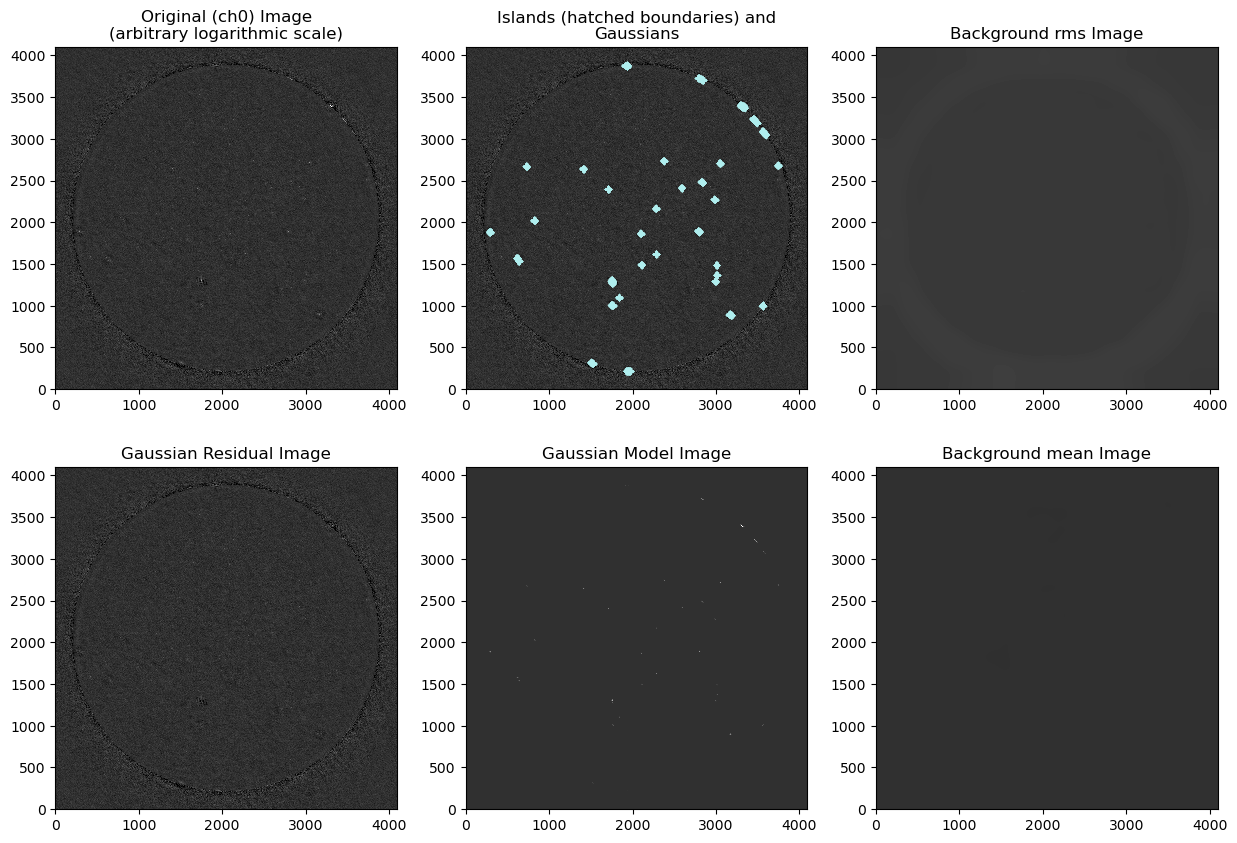

True

In [13]:
img.show_fit()

In [14]:
sources = getattr(img, "sources", [])
sources[0].__dict__
print(sources[0].posn_pix_centroid_def)


In [15]:
img.gaussians[0].__dict__

{'gaussian_idx': 0,
 'gaus_num': 0,
 'island_id': 0,
 'jlevel': 0,
 'flag': 0,
 'parameters': [214.66046328091323,
  289.2248377262899,
  1883.37755446971,
  4.584886839322598,
  2.7367230963426517,
  135.8359791054993],
 'peak_flux': 214.66046328091323,
 'centre_pix': [289.2248377262899, 1883.37755446971],
 'size_pix': [10.796583226973642, 6.444490281729603, 45.83597910549929],
 'centre_sky': [252.55749728459136, 5.238670388701934],
 'centre_skyE': (0.014341807407622245, 0.004725804592600453),
 'size_sky': (1.0044093032525492,
  0.4967628392752311,
  np.float64(52.08183483195265)),
 'size_sky_uncorr': [0.3373932258429263,
  0.2013903213040501,
  45.83597910549929],
 'size_skyE': (0.013261973432722406,
  0.01596005828781921,
  np.float32(1.6061926)),
 'size_skyE_uncorr': [np.float32(0.012158767),
  np.float32(0.004305129),
  np.float32(1.6061926)],
 'deconv_size_sky': (0.0, 0.0, 0.0),
 'deconv_size_sky_uncorr': [0.0, 0.0, 0.0],
 'deconv_size_skyE': (0.013261973432722406,
  0.0159600582

In [16]:
x_pixels = np.full(len(img.gaussians), np.nan)
y_pixels = np.full(len(img.gaussians), np.nan)
total_flux = np.full(len(img.gaussians), np.nan)
for source_ind, source in enumerate(img.gaussians):
    x_pixels[source_ind] = source.centre_pix[0]
    y_pixels[source_ind] = source.centre_pix[1]
    total_flux[source_ind] = source.total_flux

(0.0, 4096.0)

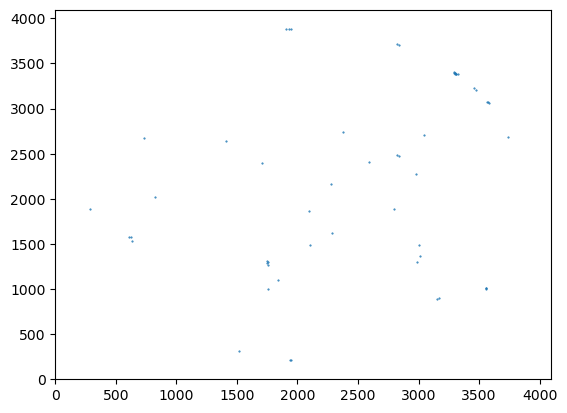

In [17]:
plt.plot(x_pixels, y_pixels, ".", markersize=1)
plt.xlim(0, 4096)
plt.ylim(0, 4096)

In [18]:
az_vals, za_vals = get_pixel_az_za(x_pixels, y_pixels, header)

(0.0, 4096.0)

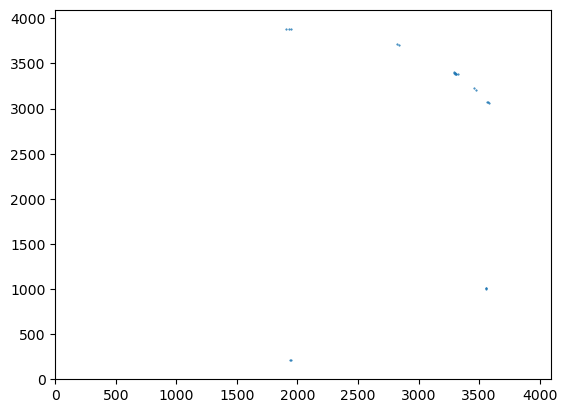

In [21]:
horizon_source_inds = np.where((za_vals > 85) + ~np.isfinite(za_vals))
plt.plot(x_pixels[horizon_source_inds], y_pixels[horizon_source_inds], ".", markersize=1)
plt.xlim(0, 4096)
plt.ylim(0, 4096)

In [66]:
proj_baseline = (
    -1 * uv.uvw_array[:, [0]] * np.cos(np.deg2rad(az_vals[np.newaxis, :]))
    + uv.uvw_array[:, [1]] * np.sin(np.deg2rad(az_vals[np.newaxis, :]))
)  # Shape (Nbls, Nsources)
wls = 3e8 / uv.freq_array
baseline_fringe = total_flux[np.newaxis, np.newaxis, :] * np.exp(
    2*np.pi*1j*proj_baseline[:, np.newaxis, :] / wls[np.newaxis, :, np.newaxis]
)  # Shape (Nbls, Nfreqs, Nsources)

In [39]:
np.shape(uv.data_array)

(745536, 1, 4)

In [67]:
baseline_fringe_summed = np.sum(baseline_fringe, axis=2)
uv_sim = uv.copy()
uv_sim.data_array[:, :, 0] = baseline_fringe_summed
uv_sim.data_array[:, :, 1] = baseline_fringe_summed
uv_sim.data_array[:, :, 2] = 0 + 0*1j
uv_sim.data_array[:, :, 3] = 0 + 0*1j
uv_sim.flag_array[...] = False
uv_sim.uvw_array[:, 2] = 0

In [68]:
uv_sim.write_ms("/fast/rbyrne/horizon_source_sim.ms", clobber=True)

The uvw_array does not match the expected values given the antenna positions. The largest discrepancy is 26.021116300662584 meters. This is a fairly common situation but might indicate an error in the antenna positions, the uvws or the phasing.


File exists; clobbering


Writing in the MS file that the units of the data are uncalib, although some CASA process will ignore this and assume the units are all in Jy (or may not know how to handle data in these units).


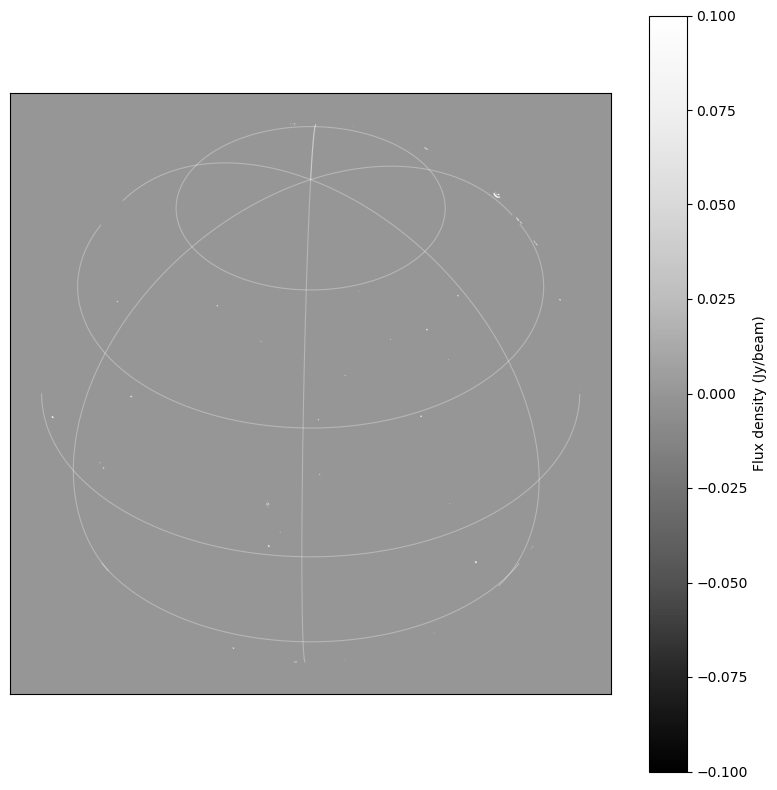

In [ ]:
with fits.open("/fast/rbyrne/20260419_055641-055832_44MHz_wsclean_selfcal_deep_flagging_tmp_dir/20260419_055641-055832_calico_peeled-dirty.fits") as hdul:
    data = hdul[0].data.squeeze()
    header = hdul[0].header

data[np.where(data < 50)] = 0

wcs = WCS(header).celestial

norm = ImageNormalize(data, interval=ZScaleInterval())

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection=wcs)
im = ax.imshow(data, origin="lower", cmap="Greys_r", norm=norm)

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.coords.grid(color="white", alpha=0.3, linestyle="solid")
fig.colorbar(im, ax=ax, label="Flux density (Jy/beam)")

plt.tight_layout()
plt.show()

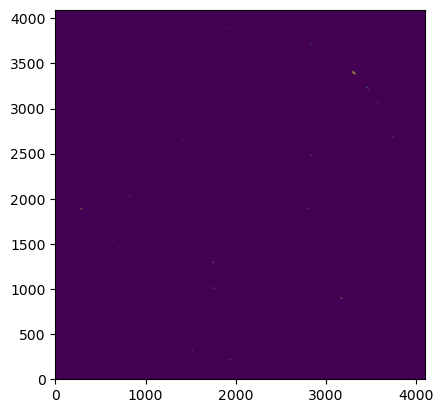

In [ ]:
plt.imshow(data, interpolation=None, origin="lower", vmin=0, vmax=100)